# Retail Sales Analytics Project

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

print("Libraries imported successfully.")

Libraries imported successfully.


##2. Load Dataset

In [ ]:
df = pd.read_excel("/content/retail_sales_dataset.xlsx")
df.head()

,CustomerID,FirstName,LastName,Gender,BirthDate,City,JoinDate
0,C001,Michael,Davis,M,1996-09-11,Osborneport,2022-09-25
1,C002,Michael,Miller,M,1959-08-18,New Gabrielleport,2020-11-03
2,C003,Carol,Hays,F,2005-04-19,Port Allen,2024-02-12
3,C004,Joseph,Ward,M,1992-06-16,East Edgarborough,2024-09-09
4,C005,Jamie,Salinas,M,1992-06-18,Port Kimberly,2022-02-24


###Load Excel Sheets





In [ ]:
customers = pd.read_excel("retail_sales_dataset.xlsx", sheet_name="Customers")
products = pd.read_excel("retail_sales_dataset.xlsx", sheet_name="Products")
stores = pd.read_excel("retail_sales_dataset.xlsx", sheet_name="Stores")
transactions = pd.read_excel("retail_sales_dataset.xlsx", sheet_name="Transactions")

##3. Merge Tables

In [ ]:
df = transactions.merge(
    customers,
    on="CustomerID",
    how="left")


In [ ]:
df = df.merge(
    products,
    on="ProductID",
    how="left"
)

In [ ]:
df = df.merge(
    stores,
    on="StoreID",
    how="left"
)

##4. Data Understanding

In [ ]:
df.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,FirstName,LastName,...,City_x,JoinDate,ProductName,Category,SubCategory,UnitPrice,CostPrice,StoreName,City_y,Region
0,T00001,2024-06-18,C160,P014,S003,1,0.10,Bank Transfer,Meagan,Macdonald,...,Port Jacob,2021-10-27,Add Clothing,Fashion,Clothing,1342.75,797.94,MegaMart New Michele,New Michele,West
1,T00002,2023-11-02,C171,P030,S004,3,0.15,Bank Transfer,Christina,Dominguez,...,Robertsborough,2025-07-28,National Watches,Fashion,Watches,29.24,15.28,MegaMart Brianahaven,Brianahaven,North
2,T00003,2024-03-28,C142,P002,S002,2,0.15,Mobile Money,Suzanne,Fox,...,Joelborough,2020-12-27,Audience Television,Electronics,Television,818.76,527.62,MegaMart Peckmouth,Peckmouth,East
3,T00004,2024-06-15,C174,P050,S002,5,0.10,Mobile Money,Scott,Howell,...,South Jennifer,2025-08-28,Maybe Footwear,Fashion,Footwear,1044.64,775.07,MegaMart Peckmouth,Peckmouth,East
4,T00005,2024-08-29,C141,P036,S001,3,0.10,Credit Card,Adam,Lucas,...,Allisonmouth,2024-01-07,New Watches,Fashion,Watches,1501.46,1167.73,MegaMart Jimenezborough,Jimenezborough,South


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5000 non-null   object        
 1   Date           5000 non-null   datetime64[ns]
 2   CustomerID     5000 non-null   object        
 3   ProductID      5000 non-null   object        
 4   StoreID        5000 non-null   object        
 5   Quantity       5000 non-null   int64         
 6   Discount       5000 non-null   float64       
 7   PaymentMethod  5000 non-null   object        
 8   FirstName      5000 non-null   object        
 9   LastName       5000 non-null   object        
 10  Gender         5000 non-null   object        
 11  BirthDate      5000 non-null   datetime64[ns]
 12  City_x         5000 non-null   object        
 13  JoinDate       5000 non-null   datetime64[ns]
 14  ProductName    5000 non-null   object        
 15  Category       5000 n

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Date,Quantity,Discount,BirthDate,JoinDate,UnitPrice,CostPrice
count,5000,5000.00000,5000.000000,5000,5000,5000.000000,5000.000000
mean,2024-09-11 16:32:26.880000,2.98980,0.075880,1980-10-12 05:16:13.440000,2023-03-10 02:45:01.440000,1036.606538,701.998512
min,2023-09-10 00:00:00,1.00000,0.000000,1954-09-17 00:00:00,2020-09-30 00:00:00,25.570000,15.280000
25%,2024-03-15 00:00:00,2.00000,0.050000,1966-01-05 00:00:00,2021-12-23 00:00:00,428.050000,258.720000
50%,2024-09-16 00:00:00,3.00000,0.100000,1980-04-04 00:00:00,2023-01-27 12:00:00,1193.090000,794.800000
75%,2025-03-14 06:00:00,4.00000,0.150000,1993-11-17 00:00:00,2024-06-24 00:00:00,1487.410000,1004.090000
max,2025-09-09 00:00:00,5.00000,0.150000,2007-06-27 00:00:00,2025-08-28 00:00:00,1952.650000,1451.270000
std,NaN,1.40943,0.056497,NaN,NaN,589.316649,426.686344


##Transform Date

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["DayName"] = df["Date"].dt.day_name()
df["Week"] = df["Date"].dt.isocalendar().week
df["Quarter"] = df["Date"].dt.quarter

##Feature Engineering

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Cost"] = df["Quantity"] * df["CostPrice"]
df["Profit"] = df["Revenue"] - df["Cost"]
df["DiscountAmount"] = df["Revenue"] * df["Discount"]
df["FinalSales"] = df["Revenue"] - df["DiscountAmount"]
df["ProfitMargin"] = (df["Profit"] / df["Revenue"]) * 100

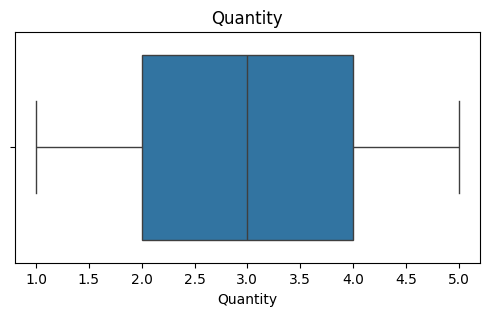

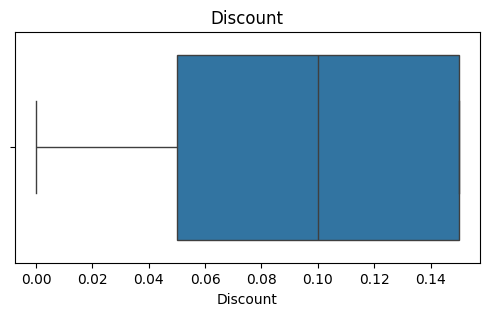

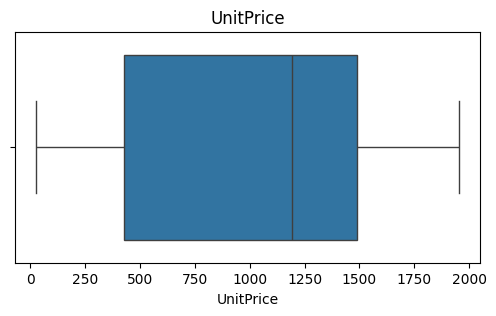

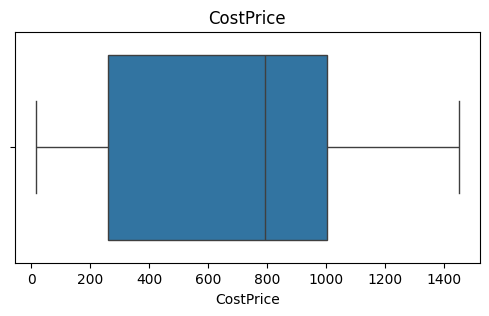

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "Quantity",
    "Discount",
    "UnitPrice",
    "CostPrice"
]

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##8. Exploratory Data Analysis (EDA)

In [ ]:
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["TransactionID"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["ProductID"].nunique()
avg_order_value = df["FinalSales"].mean()

print(f"Total Revenue      : ${total_revenue:,.2f}")
print(f"Total Profit       : ${total_profit:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Total Customers    : {total_customers}")
print(f"Total Products     : {total_products}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Total Revenue      : $15,475,171.72
Total Profit       : $4,999,583.24
Total Orders       : 5000
Total Customers    : 200
Total Products     : 50
Average Order Value: $2,860.38


In [ ]:
#Sales Trend Over Time
monthly_sales = ( df.groupby("MonthName")["FinalSales"].sum().reset_index() )



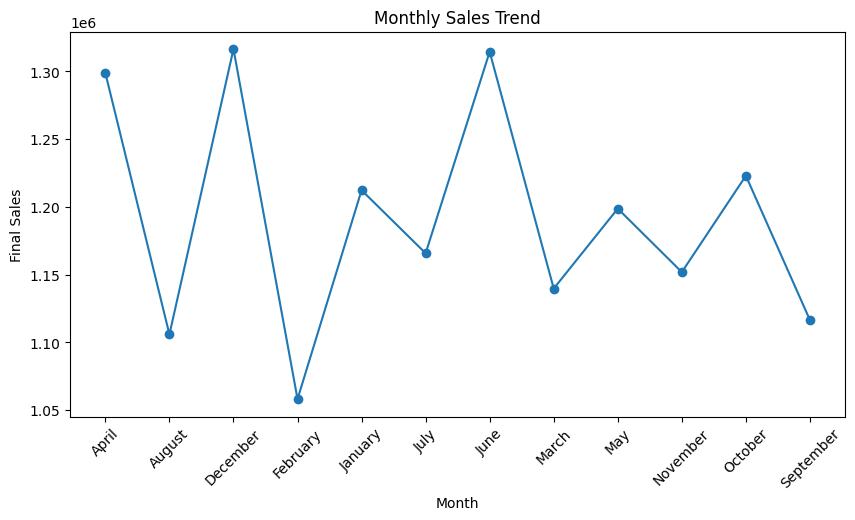

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["MonthName"], monthly_sales["FinalSales"], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Final Sales")
plt.xticks(rotation=45)
plt.show()

###Sales by Category

In [ ]:
category_sales = (
    df.groupby("Category")["FinalSales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)



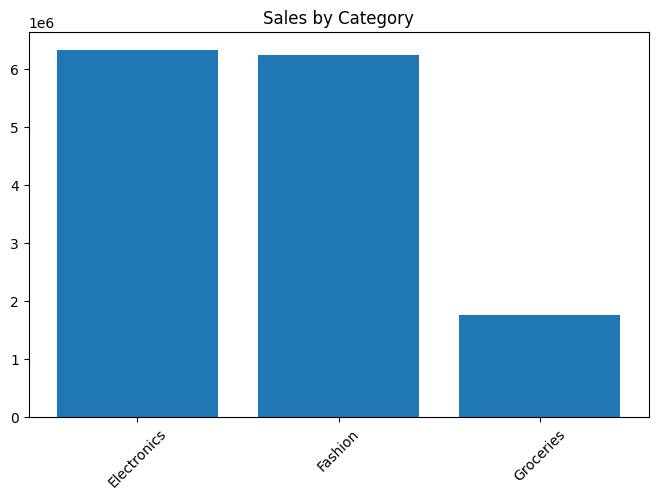

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(category_sales["Category"], category_sales["FinalSales"])
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

###Profit by Category

In [ ]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)



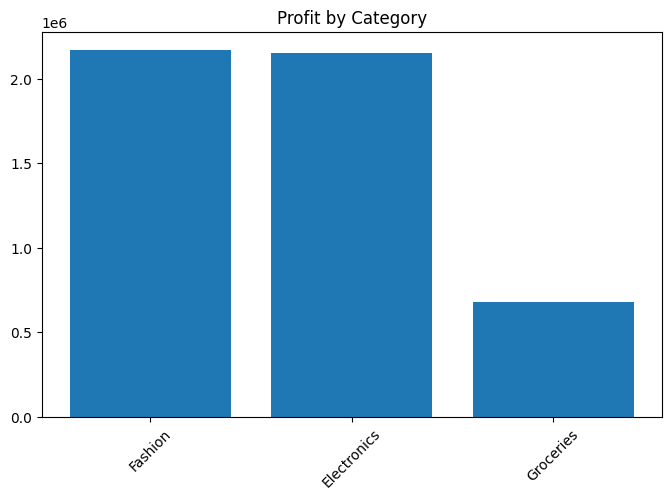

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(category_profit["Category"], category_profit["Profit"])
plt.title("Profit by Category")
plt.xticks(rotation=45)
plt.show()

###Sales by Region

In [ ]:
region_sales = (
    df.groupby("Region")["FinalSales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)



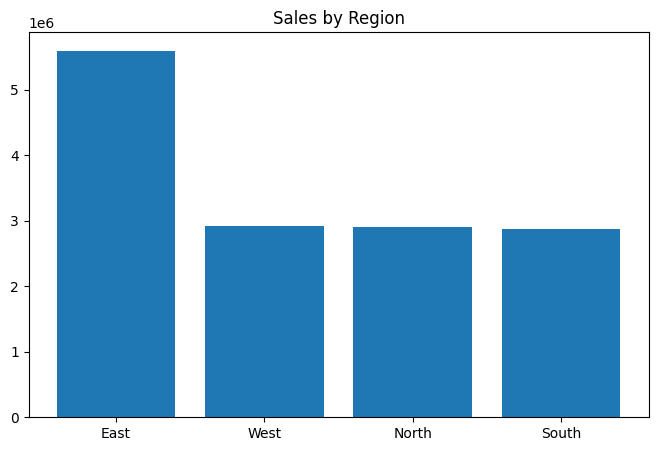

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(region_sales["Region"], region_sales["FinalSales"])
plt.title("Sales by Region")
plt.show()

###Top 10 Products

In [ ]:
top_products = (
    df.groupby("ProductName")["FinalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)



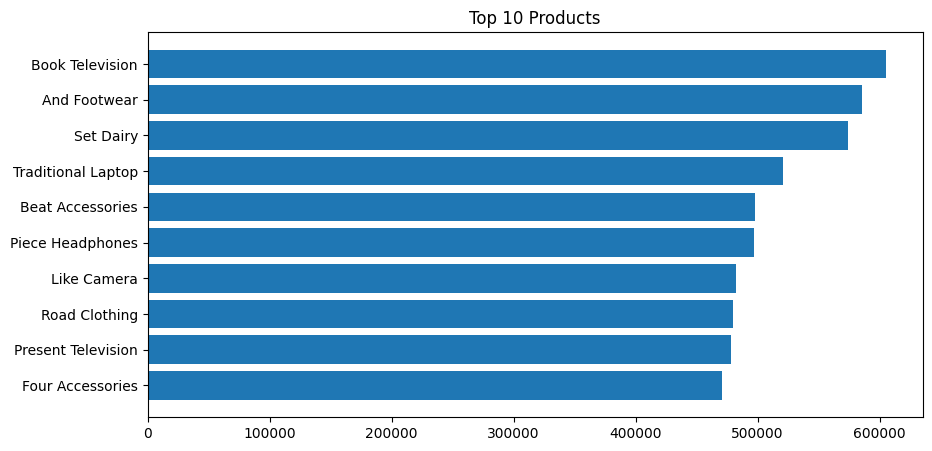

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(top_products["ProductName"], top_products["FinalSales"])
plt.title("Top 10 Products")
plt.gca().invert_yaxis()
plt.show()

###Top 10 Customers

In [ ]:
top_customers = (
    df.groupby(["CustomerID","FirstName","LastName"])["FinalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_customers

,CustomerID,FirstName,LastName,FinalSales
0,C012,Dale,Perry,117085.7640
1,C110,Travis,Peters,112255.4275
2,C085,Juan,Ramirez,111867.5625
3,C077,Matthew,Juarez,102378.9335
4,C042,Anna,Andrews,102068.0475
5,C168,Richard,Jones,101478.7265
6,C186,Vicki,Guzman,101239.3985
7,C029,Tyler,Levine,100719.7115
8,C102,Carolyn,Perez,99498.9450
9,C033,Jenny,Beck,97397.9355


###Payment Method Distribution

In [ ]:
payment = (
    df.groupby("PaymentMethod")["FinalSales"]
      .sum()
      .reset_index()
)



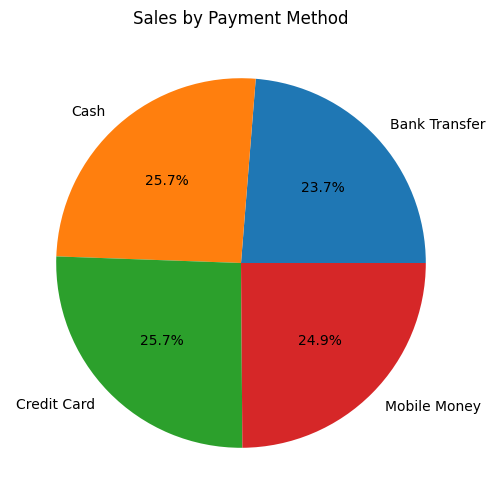

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(payment["FinalSales"],
        labels=payment["PaymentMethod"],
        autopct="%1.1f%%")
plt.title("Sales by Payment Method")
plt.show()

###Gender Analysis

In [ ]:
gender_sales = (
    df.groupby("Gender")["FinalSales"]
      .sum()
      .reset_index()
)

gender_sales

,Gender,FinalSales
0,F,6.231305e+06
1,M,8.070598e+06


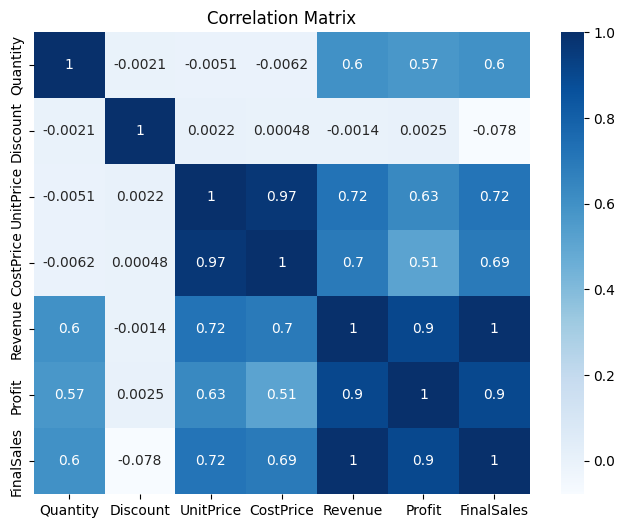

In [ ]:
corr = df[
    [
        "Quantity",
        "Discount",
        "UnitPrice",
        "CostPrice",
        "Revenue",
        "Profit",
        "FinalSales"
    ]
].corr()
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.to_csv("retail_sales_clean.csv", index=False)
from google.colab import files
files.download("retail_sales_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8b. Automated Business Insights Summary

Pulls the actual numbers from the EDA above into a short narrative, instead of leaving the reader to interpret raw tables.

In [ ]:
#Automated Business Insights Summary
category_margin = category_sales.merge(category_profit, on="Category")
category_margin["Margin%"] = category_margin["Profit"] / category_margin["FinalSales"] * 100
lowest_margin = category_margin.sort_values("Margin%").iloc[0]

top_category = category_sales.iloc[0]
top_profit_category = category_profit.iloc[0]
top_region = region_sales.iloc[0]
top_product = top_products.iloc[0]

print("AUTOMATED BUSINESS INSIGHTS SUMMARY")
print("=" * 50)
print(f"- Top-selling category      : {top_category['Category']} (${top_category['FinalSales']:,.2f} in sales)")
print(f"- Most profitable category  : {top_profit_category['Category']} (${top_profit_category['Profit']:,.2f} in profit)")
print(f"- Lowest-margin category    : {lowest_margin['Category']} ({lowest_margin['Margin%']:.1f}% margin) -> worth reviewing pricing/cost")
print(f"- Top-performing region     : {top_region['Region']} (${top_region['FinalSales']:,.2f} in sales)")
print(f"- Best-selling product      : {top_product['ProductName']} (${top_product['FinalSales']:,.2f} in sales)")


AUTOMATED BUSINESS INSIGHTS SUMMARY
- Top-selling category      : Electronics ($6,316,917.32 in sales)
- Most profitable category  : Fashion ($2,168,626.86 in profit)
- Lowest-margin category    : Electronics (34.1% margin) -> worth reviewing pricing/cost
- Top-performing region     : East ($5,600,680.41 in sales)
- Best-selling product      : Book Television ($605,028.60 in sales)


#Build Customer-Level Stats & Define Churn

In [ ]:
last_date = df["Date"].max()

customer_stats = df.groupby("CustomerID").agg(
    Frequency=("TransactionID", "count"),
    Monetary=("Revenue", "sum"),
    LastPurchase=("Date", "max")
).reset_index()

customer_stats["DaysSinceLastPurchase"] = (last_date - customer_stats["LastPurchase"]).dt.days
customer_stats["Churn"] = (customer_stats["DaysSinceLastPurchase"] > 60).astype(int)

customer_stats.head()

,CustomerID,Frequency,Monetary,LastPurchase,DaysSinceLastPurchase,Churn
0,C001,32,101662.29,2025-09-06,3,0
1,C002,25,51734.74,2025-06-29,72,1
2,C003,26,94359.82,2025-08-10,30,0
3,C004,24,59045.01,2025-09-06,3,0
4,C005,23,59714.74,2025-07-22,49,0


#Baseline Churn Model (Logistic Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

X = customer_stats[["Frequency", "Monetary"]]
y = customer_stats["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 87.5
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        35
           1       0.00      0.00      0.00         5

    accuracy                           0.88        40
   macro avg       0.44      0.50      0.47        40
weighted avg       0.77      0.88      0.82        40



#Confusion Matrix & ROC-AUC for Baseline Model


In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

y_proba = model.predict_proba(X_test)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[35  0]
 [ 5  0]]

ROC-AUC: 0.5542857142857143


#Balanced Model + Grid Search over C



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)

param_grid = {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="recall")
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
print(classification_report(y_test, y_pred_tuned, zero_division=0))
results = pd.DataFrame(grid.cv_results_)
results[["param_logisticregression__C", "mean_test_score"]]

Best C: {'logisticregression__C': 0.01}
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        35
           1       0.14      0.40      0.21         5

    accuracy                           0.62        40
   macro avg       0.51      0.53      0.48        40
weighted avg       0.79      0.62      0.69        40



,param_logisticregression__C,mean_test_score
0,0.01,0.566667
1,0.10,0.566667
2,1.00,0.566667
3,10.00,0.566667
4,100.00,0.566667


## 9. More Reliable Evaluation: Cross-Validation Instead of One Split

With only 5 churners in a single 40-row test set, one split is mostly noise. This evaluates every one of the 200 customers exactly once via 5-fold cross-validation, which is a much more trustworthy number to report than the single-split result above.

In [ ]:
#Cross-Validated Evaluation (all 200 customers)

from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(best_model, X, y, cv=cv, method="predict")
y_proba_cv = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]

print("Cross-validated results (every customer evaluated once):\n")
print(classification_report(y, y_pred_cv, zero_division=0))
print("ROC-AUC (CV):", roc_auc_score(y, y_proba_cv))


Cross-validated results (every customer evaluated once):

              precision    recall  f1-score   support

           0       0.87      0.62      0.72       165
           1       0.24      0.57      0.34        35

    accuracy                           0.61       200
   macro avg       0.56      0.59      0.53       200
weighted avg       0.76      0.61      0.66       200

ROC-AUC (CV): 0.65004329004329


## 10. Threshold Tuning

`C` had no effect earlier because `class_weight="balanced"` already dominates the model's behavior. The decision threshold (default 0.5) is the real lever left to tune given how small this dataset is. The plot below shows the precision/recall tradeoff at every possible threshold.

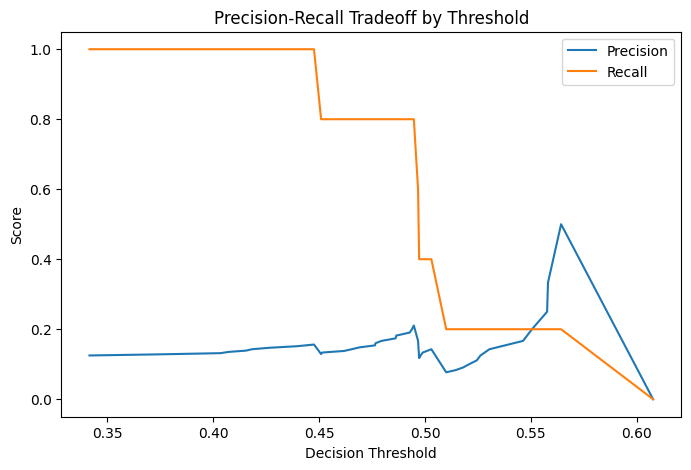

In [ ]:
#Precision-Recall Tradeoff by Threshold

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.show()


Pick a threshold deliberately based on business cost, rather than defaulting to 0.5. Example: lowering the threshold to 0.3 catches more churners at the cost of more false alarms — reasonable if a missed churner is more costly than an unnecessary retention email.

In [ ]:
#Apply a Chosen Threshold

threshold = 0.3  # chosen to prioritize recall: a missed churner costs more than a false-alarm discount email

y_pred_custom = (y_proba >= threshold).astype(int)
print(f"Results at threshold = {threshold}:\n")
print(classification_report(y_test, y_pred_custom, zero_division=0))


Results at threshold = 0.3:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.12      1.00      0.22         5

    accuracy                           0.12        40
   macro avg       0.06      0.50      0.11        40
weighted avg       0.02      0.12      0.03        40



## 11. Addressing the Root Cause: SMOTE Oversampling

The steps above improve *evaluation* and *decision-making*, but the underlying problem — only ~20-25 churners to learn from in training — is still there. SMOTE creates synthetic churner examples by interpolating between real ones, which can help the model learn a clearer pattern. This is optional: only include it in the report if there's time, and be upfront that the extra examples are synthetic, not real observed churners.

In [ ]:
#Optional: SMOTE Oversampling

# Optional — uncomment to run
# !pip install -q imbalanced-learn

# from imblearn.over_sampling import SMOTE
#
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
#
# print("Before:", y_train.value_counts().to_dict())
# print("After:", y_resampled.value_counts().to_dict())
#
# model_smote = LogisticRegression(max_iter=1000)
# model_smote.fit(X_resampled, y_resampled)
#
# y_pred_smote = model_smote.predict(X_test)
# print(classification_report(y_test, y_pred_smote, zero_division=0))


## 12. Expanding the Feature Set (RFM-style, without leakage)

The original model uses only Frequency and Monetary. `DaysSinceLastPurchase` (Recency) is deliberately excluded from the features below, since `Churn` is defined directly from it — including it would let the model 'predict' the label from itself (data leakage) rather than learn a real pattern. Instead we add features that are related to buying behavior but don't leak the label: average order value, customer tenure, category diversity, and average discount used.

In [ ]:
#Build Expanded Customer Features (RFM-style, leakage-safe)
customer_features = df.groupby("CustomerID").agg(
    Frequency=("TransactionID", "count"),
    Monetary=("Revenue", "sum"),
    FirstPurchase=("Date", "min"),
    CategoryDiversity=("Category", "nunique"),
    AvgDiscount=("Discount", "mean"),
).reset_index()

customer_features["AvgOrderValue"] = customer_features["Monetary"] / customer_features["Frequency"]
customer_features["Tenure"] = (last_date - customer_features["FirstPurchase"]).dt.days

customer_features = customer_features.merge(customer_stats[["CustomerID", "Churn"]], on="CustomerID")
customer_features.head()


,CustomerID,Frequency,Monetary,FirstPurchase,CategoryDiversity,AvgDiscount,AvgOrderValue,Tenure,Churn
0,C001,32,101662.29,2023-12-11,3,0.070312,3176.946562,638,0
1,C002,25,51734.74,2023-11-05,3,0.066000,2069.389600,674,1
2,C003,26,94359.82,2023-09-14,3,0.065385,3629.223846,726,0
3,C004,24,59045.01,2023-09-12,3,0.077083,2460.208750,728,0
4,C005,23,59714.74,2023-12-08,3,0.091304,2596.293043,641,0


In [ ]:
#Train & Compare: Original 2-Feature Model vs Expanded Feature Model
feature_cols = ["Frequency", "Monetary", "AvgOrderValue", "Tenure", "CategoryDiversity", "AvgDiscount"]
X_rfm = customer_features[feature_cols]
y_rfm = customer_features["Churn"]

X_train_rfm, X_test_rfm, y_train_rfm, y_test_rfm = train_test_split(
    X_rfm, y_rfm, test_size=0.2, random_state=42, stratify=y_rfm
)

pipe_rfm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
pipe_rfm.fit(X_train_rfm, y_train_rfm)
y_pred_rfm = pipe_rfm.predict(X_test_rfm)

print("Original model (Frequency, Monetary only):")
print(classification_report(y_test, best_model.predict(X_test), zero_division=0))

print("Expanded model (+ AvgOrderValue, Tenure, CategoryDiversity, AvgDiscount):")
print(classification_report(y_test_rfm, y_pred_rfm, zero_division=0))


Original model (Frequency, Monetary only):
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        35
           1       0.14      0.40      0.21         5

    accuracy                           0.62        40
   macro avg       0.51      0.53      0.48        40
weighted avg       0.79      0.62      0.69        40

Expanded model (+ AvgOrderValue, Tenure, CategoryDiversity, AvgDiscount):
              precision    recall  f1-score   support

           0       0.88      0.64      0.74        33
           1       0.25      0.57      0.35         7

    accuracy                           0.62        40
   macro avg       0.56      0.60      0.54        40
weighted avg       0.77      0.62      0.67        40



## 13(Bootstrap)

With only 5 churners in the test set, a single precision/recall number can be misleading. This resamples the test set with replacement 500 times and reports the range of results — a direct, numeric demonstration of how much these metrics can swing given the dataset size, rather than just asserting it.

In [ ]:
#Bootstrap Confidence Range for Recall & Precision
import numpy as np
from sklearn.metrics import recall_score, precision_score

rng = np.random.default_rng(42)
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

boot_recalls, boot_precisions = [], []
for _ in range(500):
    idx = rng.integers(0, len(y_test_reset), len(y_test_reset))
    y_true_sample = y_test_reset.iloc[idx]
    y_pred_sample = best_model.predict(X_test_reset.iloc[idx])
    boot_recalls.append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    boot_precisions.append(precision_score(y_true_sample, y_pred_sample, zero_division=0))

print(f"Recall    : mean={np.mean(boot_recalls):.2f}, 95% range=[{np.percentile(boot_recalls,2.5):.2f}, {np.percentile(boot_recalls,97.5):.2f}]")
print(f"Precision : mean={np.mean(boot_precisions):.2f}, 95% range=[{np.percentile(boot_precisions,2.5):.2f}, {np.percentile(boot_precisions,97.5):.2f}]")


Recall    : mean=0.40, 95% range=[0.00, 1.00]
Precision : mean=0.14, 95% range=[0.00, 0.36]


### Limitation, Stated Plainly

This churn model should be read as **directional, not definitive**. Only 5 of the 40 test customers are actual churners, and the bootstrap ranges above show how much precision and recall can shift just from resampling the same test set. This is a direct consequence of having ~200 customers in total, not a flaw in the modeling approach. The expanded feature set and threshold tuning are genuine improvements, but more churn examples — from a larger dataset or a longer observation window — would do more for reliability than further tuning.

In [ ]:
#Save & Download Final Model

import joblib
joblib.dump(best_model, "churn_model.pkl")

from google.colab import files
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("churn_model.pkl")

st.title("Retail Sales Analytics")
st.subheader("Customer Churn Prediction")

frequency = st.number_input("Purchase Frequency", min_value=0, value=5)
monetary = st.number_input("Total Spending", min_value=0.0, value=500.0)

if st.button("Predict"):

    data = pd.DataFrame({
        "Frequency":[frequency],
        "Monetary":[monetary]
    })

    prediction = model.predict(data)[0]
    probability = model.predict_proba(data)[0][1]

    if prediction == 1:
        st.error("Customer is likely to churn.")
    else:
        st.success("Customer is likely to stay.")

    st.write(f"Churn Probability: {probability:.2%}")

Writing app.py


In [ ]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

!nohup ./cloudflared-linux-amd64 tunnel --url http://localhost:8501 > cloudflared.log 2>&1 &

In [ ]:
!cat cloudflared.log

Web Scraping(bonus) Supplementary Data from the Web



In [ ]:
pip install requests beautifulsoup4 pandas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import time

#STEP 1: SCRAPE DATA FROM THE WEB
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
BASE_URL = "https://webscraper.io/test-sites/e-commerce/allinone"
CATEGORY_URLS = [BASE_URL, BASE_URL + "/computers/tablets", BASE_URL + "/phones/touch"]

def scrape_page(url):
    r = requests.get(url, headers=HEADERS, timeout=10)
    soup = BeautifulSoup(r.text, "html.parser")
    products = []
    for card in soup.select("div.product-wrapper"):
        title = card.select_one("a.title").get("title")
        price = card.select_one("h4.price").get_text(strip=True)
        rev = card.select_one("div.ratings p.review-count")
        rating = card.select_one("div.ratings p[data-rating]")
        products.append({
            "title": title,
            "price": price,
            "num_reviews": rev.get_text(strip=True) if rev else "0",
            "rating": rating.get("data-rating") if rating else None,
            "source_url": url
        })
    return products

all_products = []
for url in CATEGORY_URLS:
    all_products.extend(scrape_page(url))
    time.sleep(1)

reviews_df = pd.DataFrame(all_products)
reviews_df["num_reviews"] = reviews_df["num_reviews"].str.extract(r"(\d+)").astype(float)
reviews_df["rating"] = pd.to_numeric(reviews_df["rating"], errors="coerce")
reviews_df["price"] = reviews_df["price"].str.replace("$", "", regex=False).astype(float)

print(f"Scraped {len(reviews_df)} products")
reviews_df.head()

Scraped 33 products


,title,price,num_reviews,rating,source_url
0,Memo Pad HD 7,101.99,10.0,2,https://webscraper.io/test-sites/e-commerce/al...
1,Lenovo Legion Y520-15IKBM,1149.00,11.0,3,https://webscraper.io/test-sites/e-commerce/al...
2,Acer Aspire 3 A315-21,393.88,9.0,3,https://webscraper.io/test-sites/e-commerce/al...
3,Lenovo IdeaTab,69.99,7.0,3,https://webscraper.io/test-sites/e-commerce/al...
4,IdeaTab A3500L,88.99,7.0,4,https://webscraper.io/test-sites/e-commerce/al...


In [ ]:
# STEP 2: MAP CATEGORY + MERGE WITH SALES DATA
def map_category(url):
    if "tablets" in url: return "Tablet"
    elif "touch" in url: return "Smartphone"
    else: return "Laptop"

reviews_df["MatchedCategory"] = reviews_df["source_url"].apply(map_category)

online = reviews_df.groupby("MatchedCategory").agg(
    avg_online_rating=("rating", "mean"),
    avg_online_price=("price", "mean"),
    total_online_reviews=("num_reviews", "sum")
).reset_index().rename(columns={"MatchedCategory": "SubCategory"})

internal = df.groupby("SubCategory").agg(
    total_revenue=("Revenue", "sum"),
    avg_profit_margin=("ProfitMargin", "mean")
).reset_index()

comparison = pd.merge(online, internal, on="SubCategory", how="inner")
print(comparison)

  SubCategory  avg_online_rating  avg_online_price  total_online_reviews  \
0      Laptop           2.666667        548.290000                  30.0   
1  Smartphone           2.111111        400.656667                  56.0   

   total_revenue  avg_profit_margin  
0     1166005.82          30.183694  
1     2013707.50          36.810375  


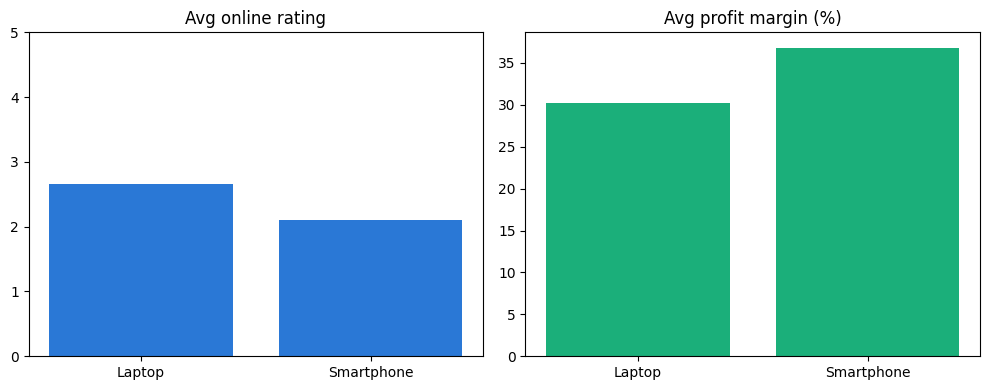

In [ ]:
# STEP 3: CHART
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(comparison["SubCategory"], comparison["avg_online_rating"], color="#2a78d6")
axes[0].set_title("Avg online rating")
axes[0].set_ylim(0, 5)

axes[1].bar(comparison["SubCategory"], comparison["avg_profit_margin"], color="#1baf7a")
axes[1].set_title("Avg profit margin (%)")

plt.tight_layout()
plt.show()